In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications.efficientnet import preprocess_input
import zipfile
import os
import seaborn as sns
from PIL import Image

In [3]:
ZIP_PATH = "/content/drive/MyDrive/Srintami/new-dataset2.zip"
DATASET_PATH = "/content"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
  for member in zip_ref.namelist():
    if not member.startswith('__MACOSX/'):
      zip_ref.extract(member, DATASET_PATH)

print("Berhasil di extract")

Berhasil di extract


In [2]:
data_path = "/content/new-dataset2"

In [3]:
img_size = 256
batch_size = 16
epochs = 30
learning_rate = 0.0001
seed = 123

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.3,
    subset="training",
    seed=seed,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.3,
    subset="validation",
    seed=seed,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

class_names = train_ds.class_names

print(class_names)

Found 8199 files belonging to 7 classes.
Using 5740 files for training.
Found 8199 files belonging to 7 classes.
Using 2459 files for validation.
['aksesoris cold', 'aksesoris hot', 'arcing horn', 'bracing', 'isolator', 'jumper', 'pondasi']


In [5]:
temp_batches = tf.data.experimental.cardinality(temp_ds)
val_size = temp_batches // 2
val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomBrightness(0.1),
    # tf.keras.layers.RandomTranslation(0.1, 0.1)
])

train_ds = train_ds.map(
    lambda x, y: (
        data_augmentation(x, training=True),
        y
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

# train_ds = train_ds.map(
#     lambda x, y: (
#         preprocess_input(
#             data_augmentation(x, training=True)
#         ),
#         y
#     ),
#     num_parallel_calls=tf.data.AUTOTUNE
# )

# val_ds = val_ds.map(
#     lambda x, y: (
#         preprocess_input(x),
#         y
#     ),
#     num_parallel_calls=tf.data.AUTOTUNE
# )

# test_ds = test_ds.map(
#     lambda x, y: (
#         preprocess_input(x),
#         y
#     ),
#     num_parallel_calls=tf.data.AUTOTUNE
# )

In [7]:
Autotune = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size=Autotune)
)

val_ds = (
    val_ds
    .cache()
    .prefetch(buffer_size=Autotune)
)

test_ds = (
    test_ds
    .cache()
    .prefetch(buffer_size=Autotune)
)

In [ ]:
def count_classes(dataset, class_names):
    class_counts = {name: 0 for name in class_names}
    for _, labels in dataset:
        for label in labels.numpy():
            class_counts[class_names[label]] += 1
    return class_counts

print('Class distribution in training set:')
train_class_counts = count_classes(train_ds, class_names)
for class_name, count in train_class_counts.items():
    print(f"  {class_name}: {count} images")

print('\nClass distribution in validation set:')
val_class_counts = count_classes(val_ds, class_names)
for class_name, count in val_class_counts.items():
    print(f"  {class_name}: {count} images")

print('\nClass distribution in test set:')
test_class_counts = count_classes(test_ds, class_names)
for class_name, count in test_class_counts.items():
    print(f"  {class_name}: {count} images")

Class distribution in training set:
  aksesoris cold: 809 images
  aksesoris hot: 774 images
  arcing horn: 797 images
  bracing: 814 images
  isolator: 888 images
  jumper: 846 images
  pondasi: 812 images

Class distribution in validation set:


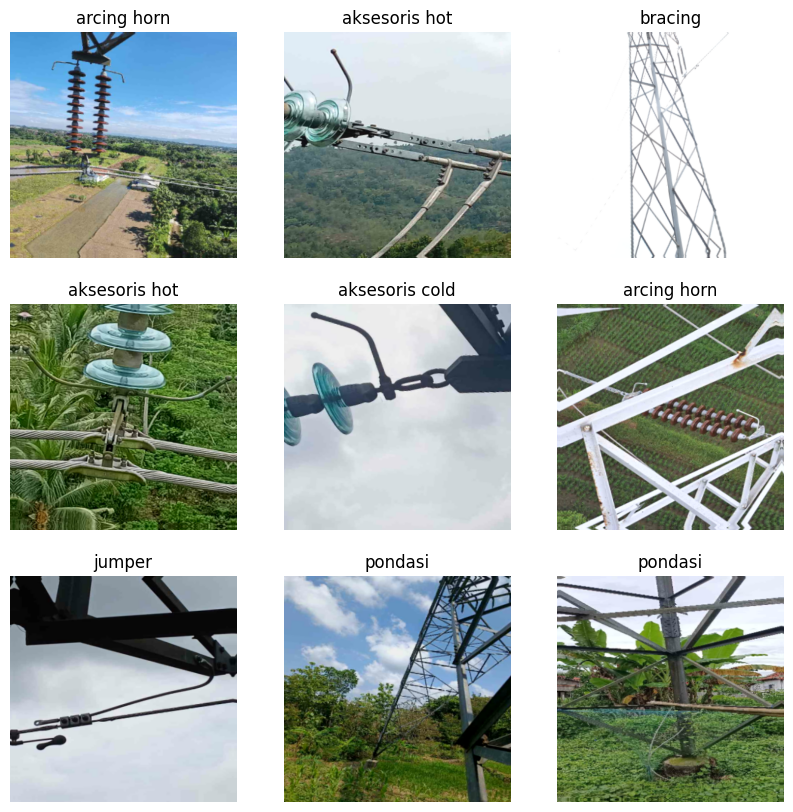

In [8]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [8]:
base_model = tf.keras.applications.EfficientNetB0(input_shape=(img_size, img_size, 3),
                                                  include_top=False,
                                                  weights='imagenet')

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.Input(shape=(img_size, img_size, 3)),
    # data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(7, activation='softmax')
])

In [9]:
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model.compile (
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping]
)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 257s 162ms/step - accuracy: 0.4720 - loss: 1.4569 - val_accuracy: 0.6469 - val_loss: 1.0972
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.6890 - loss: 0.9898 - val_accuracy: 0.7281 - val_loss: 0.8456
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7465 - loss: 0.8090 - val_accuracy: 0.7614 - val_loss: 0.7277
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7742 - loss: 0.7083 - val_accuracy: 0.7946 - val_loss: 0.6466
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7892 - loss: 0.6437 - val_accuracy: 0.8003 - val_loss: 0.6036
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8082 - loss: 0.5906 - val_accuracy: 0.8093 - val_loss: 0.5736
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.8206 - loss: 0.5567 - val_accuracy: 0.8133 - val_loss: 0.5436
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8253 - loss: 0.5307 

77/77 ━━━━━━━━━━━━━━━━━━━━ 60s 518ms/step - accuracy: 0.8680 - loss: 0.3683

Test Loss: 0.3683
Test Accuracy: 0.8680
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━

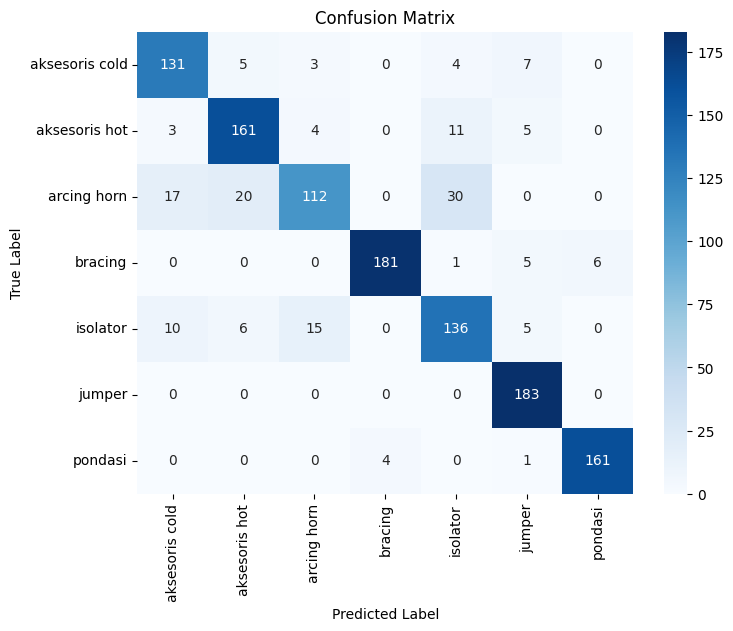

In [13]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

y_pred_raw = []
y_true = []

for images, labels in test_ds:
    predictions = model.predict(images)
    y_pred_raw.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

y_pred = np.array(y_pred_raw)
y_true = np.array(y_true)

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Saving insulator2.jpg to insulator2 (2).jpg
File upload "insulator2 (2).jpg"
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


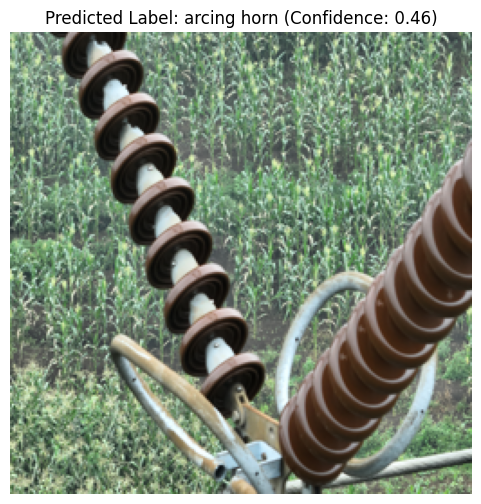


Confidence for each class:
  aksesoris cold: 0.0415
  aksesoris hot: 0.2603
  arcing horn: 0.4562
  bracing: 0.0000
  isolator: 0.2420
  jumper: 0.0000
  pondasi: 0.0000


In [21]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('File upload "{name}"'.format(
      name=fn, length=len(uploaded[fn])))
  uploaded_image_path = fn
  break

if 'uploaded_image_path' in locals():
    try:
        img = Image.open(uploaded_image_path)

        img = img.resize((img_size, img_size))

        img_array = np.array(img)

        if img_array.ndim == 2:
            img_array = np.stack([img_array, img_array, img_array], axis=-1)
        elif img_array.shape[-1] == 4:
            img_array = img_array[..., :3]

        img_for_prediction = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_for_prediction)
        predicted_class_index = np.argmax(predictions[0])
        predicted_class_name = class_names[predicted_class_index]
        confidence = np.max(predictions[0])

        plt.figure(figsize=(6, 6))
        plt.imshow(img_array.astype('uint8'))
        plt.title(f"Predicted Label: {predicted_class_name} (Confidence: {confidence:.2f})")
        plt.axis('off')
        plt.show()

        # print(f"Raw predictions: {predictions[0]}")
        print("\nConfidence for each class:")
        for i, conf_score in enumerate(predictions[0]):
            print(f"  {class_names[i]}: {conf_score:.4f}")

    except Exception as e:
        print(f"An error occurred during image processing or prediction: {e}")
else:
    print("Please upload an image to proceed.")

In [ ]:
model.save_weights("model.weights.h5")

In [ ]:
model.save('image_classification_model.h5', save_format='h5')

In [ ]:
model.save('image_classification.keras')

In [ ]:
from google.colab import files

files.download('model.weights.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
model.export("saved_model")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_243')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  139610796975184: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139610796976528: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139611186688656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139611186687696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139611186689232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139611186690000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139611186690576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139611186688848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139611186689040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139611186690384: TensorSpec(shape=(), dtype=tf.resource, name=None)

In [23]:
import shutil

shutil.make_archive(
    "saved_model",
    "zip",
    "saved_model"
)

'/content/saved_model.zip'